# Rough Volatility and HJB — standalone notebook

This notebook contains direct copies of the project classes and numerical functions in dependency order. It does not import any local project module, so the file can be downloaded and executed independently after installing NumPy and Matplotlib.

The article-facing covariance plots aggregate matrix errors along constant-lag diagonals using mean absolute error. The fBM article figures use the Davies–Harte FFT construction; direct Cholesky simulation remains available as a reference implementation.

In [1]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
print('Standalone runtime ready:', np.__version__)


Standalone runtime ready: 2.1.0


## Rough-process models and numerical helpers

Embedded from `rough_processes.py`.

In [2]:
"""Reusable, class-based rough-process simulators.

The public functions at the bottom preserve the original command-line API.
The classes centralize validation and cache deterministic matrices so callers
that redraw paths on the same grid do not rebuild covariance or kernel data.
"""


from dataclasses import dataclass
from functools import cached_property
from math import gamma
from pathlib import Path

import numpy as np


def _positive_int(value: int, name: str, minimum: int = 1) -> int:
    result = int(value)
    if result < minimum:
        raise ValueError(f"{name} must be at least {minimum}")
    return result


def _validate_hurst(hurst: float) -> float:
    result = float(hurst)
    if not 0.0 < result < 1.0:
        raise ValueError("hurst must lie strictly between 0 and 1")
    return result


@dataclass(frozen=True)
class SimulationGrid:
    """Validated time discretization shared by all process models."""

    steps: int = 300
    horizon: float = 1.0

    def __post_init__(self) -> None:
        object.__setattr__(self, "steps", _positive_int(self.steps, "steps", 3))
        horizon = float(self.horizon)
        if horizon <= 0.0:
            raise ValueError("horizon must be positive")
        object.__setattr__(self, "horizon", horizon)

    @cached_property
    def time(self) -> np.ndarray:
        return np.linspace(0.0, self.horizon, self.steps)

    @property
    def dt(self) -> float:
        return float(self.time[1] - self.time[0])


@dataclass(frozen=True)
class FractionalBrownianMotion:
    """fBM covariance model with a cached Cholesky factor."""

    grid: SimulationGrid
    hurst: float = 0.5
    jitter: float = 1e-10

    def __post_init__(self) -> None:
        object.__setattr__(self, "hurst", _validate_hurst(self.hurst))

    @cached_property
    def covariance(self) -> np.ndarray:
        time = self.grid.time
        tt = time[:, None]
        ss = time[None, :]
        exponent = 2.0 * self.hurst
        return 0.5 * (tt**exponent + ss**exponent - np.abs(tt - ss) ** exponent)

    @cached_property
    def cholesky(self) -> np.ndarray:
        return np.linalg.cholesky(self.covariance + self.jitter * np.eye(self.grid.steps))

    def simulate(self, paths: int = 10, seed: int = 42) -> np.ndarray:
        count = _positive_int(paths, "paths")
        draws = np.random.default_rng(seed).standard_normal((self.grid.steps, count))
        return (self.cholesky @ draws).T


@dataclass(frozen=True)
class DaviesHarteFractionalBrownianMotion:
    """FFT-based fBM simulator built from fractional Gaussian increments.

    The direct-covariance class above remains useful as a small-grid reference.
    This class matches the Davies--Harte construction described in the article
    and fixes the initial value exactly at zero.
    """

    grid: SimulationGrid
    hurst: float = 0.5
    eigenvalue_tolerance: float = 1e-12

    def __post_init__(self) -> None:
        object.__setattr__(self, "hurst", _validate_hurst(self.hurst))
        tolerance = float(self.eigenvalue_tolerance)
        if tolerance <= 0.0:
            raise ValueError("eigenvalue_tolerance must be positive")
        object.__setattr__(self, "eigenvalue_tolerance", tolerance)

    @property
    def increment_count(self) -> int:
        return self.grid.steps - 1

    @cached_property
    def increment_covariance(self) -> np.ndarray:
        lag = np.arange(self.increment_count, dtype=float)
        exponent = 2.0 * self.hurst
        covariance = 0.5 * (
            np.abs(lag + 1.0) ** exponent
            - 2.0 * np.abs(lag) ** exponent
            + np.abs(lag - 1.0) ** exponent
        )
        return (self.grid.dt ** exponent) * covariance

    @cached_property
    def embedding_eigenvalues(self) -> np.ndarray:
        covariance = self.increment_covariance
        embedding = np.concatenate((covariance, [0.0], covariance[1:][::-1]))
        eigenvalues = np.fft.fft(embedding).real
        tolerance = self.eigenvalue_tolerance * max(1.0, float(eigenvalues.max()))
        if float(eigenvalues.min()) < -tolerance:
            raise ValueError("Davies--Harte circulant embedding is not positive")
        return np.maximum(eigenvalues, 0.0)

    def simulate(self, paths: int = 10, seed: int = 42) -> np.ndarray:
        count = _positive_int(paths, "paths")
        embedding_size = 2 * self.increment_count
        draws = np.random.default_rng(seed).standard_normal((count, embedding_size))
        increments = np.fft.ifft(
            np.fft.fft(draws, axis=1) * np.sqrt(self.embedding_eigenvalues),
            axis=1,
        ).real[:, : self.increment_count]
        samples = np.zeros((count, self.grid.steps), dtype=float)
        samples[:, 1:] = np.cumsum(increments, axis=1)
        return samples

    @cached_property
    def covariance(self) -> np.ndarray:
        return fbm_covariance(self.grid.time, self.hurst)


@dataclass(frozen=True)
class VolterraProcess:
    """Causal Volterra representation with a vectorized kernel build."""

    grid: SimulationGrid
    hurst: float = 0.5

    def __post_init__(self) -> None:
        object.__setattr__(self, "hurst", _validate_hurst(self.hurst))

    @cached_property
    def kernel(self) -> np.ndarray:
        steps = self.grid.steps
        if abs(self.hurst - 0.5) < 1e-12:
            kernel = np.zeros((steps, steps), dtype=float)
            kernel[np.tril_indices(steps, -1)] = 1.0
            return kernel

        time = self.grid.time
        lag = time[:, None] - time[None, :]
        causal = lag > 0.0
        coefficient = gamma(2.0 * self.hurst + 1.0) / (
            2.0 * gamma(self.hurst + 0.5) ** 2
        )
        kernel = np.zeros_like(lag)
        kernel[causal] = np.sqrt(coefficient) * np.maximum(
            lag[causal], self.grid.dt
        ) ** (self.hurst - 0.5)
        return kernel

    def simulate(self, paths: int = 10, seed: int = 77) -> tuple[np.ndarray, np.ndarray]:
        count = _positive_int(paths, "paths")
        rng = np.random.default_rng(seed)
        increments = rng.normal(
            0.0, np.sqrt(self.grid.dt), size=(count, self.grid.steps)
        )
        process = increments @ self.kernel.T
        brownian = np.cumsum(increments, axis=1)
        return process, brownian


@dataclass(frozen=True)
class MarkovianLift:
    """Finite OU lifting with cached rates, weights, and innovation factor."""

    grid: SimulationGrid
    hurst: float = 0.5
    factors: int = 10
    lambda_min: float | None = None
    lambda_max: float | None = None
    jitter: float = 1e-12

    def __post_init__(self) -> None:
        object.__setattr__(self, "hurst", _validate_hurst(self.hurst))
        object.__setattr__(self, "factors", _positive_int(self.factors, "factors"))
        lower = 2.0 / self.grid.horizon if self.lambda_min is None else float(self.lambda_min)
        upper = 400.0 / self.grid.horizon if self.lambda_max is None else float(self.lambda_max)
        if not 0.0 < lower < upper:
            raise ValueError("lambda bounds must satisfy 0 < lambda_min < lambda_max")
        object.__setattr__(self, "lambda_min", lower)
        object.__setattr__(self, "lambda_max", upper)

    @cached_property
    def rates(self) -> np.ndarray:
        return np.logspace(
            np.log10(float(self.lambda_min)),
            np.log10(float(self.lambda_max)),
            self.factors,
        )

    @cached_property
    def weights(self) -> np.ndarray:
        weights = self.rates ** (-(self.hurst + 0.5))
        return weights / weights.sum()

    @cached_property
    def decay(self) -> np.ndarray:
        return np.exp(-self.rates * self.grid.dt)

    @cached_property
    def innovation_covariance(self) -> np.ndarray:
        rate_sum = self.rates[:, None] + self.rates[None, :]
        return (1.0 - np.exp(-rate_sum * self.grid.dt)) / rate_sum

    @cached_property
    def innovation_cholesky(self) -> np.ndarray:
        return np.linalg.cholesky(
            self.innovation_covariance + self.jitter * np.eye(self.factors)
        )

    def simulate(
        self,
        paths: int = 10,
        seed: int = 101,
        match_marginals: bool = True,
    ) -> np.ndarray:
        """Simulate all paths together, leaving only the time recursion in Python.

        Complexity is O(N P M^2) for N steps, P paths, and M OU factors, but
        the former P-by-N Python loop is reduced to N batched BLAS operations.
        """

        count = _positive_int(paths, "paths")
        rng = np.random.default_rng(seed)
        draws = rng.standard_normal((count, self.grid.steps - 1, self.factors))
        innovations = draws @ self.innovation_cholesky.T
        state = np.zeros((count, self.factors), dtype=float)
        lifted = np.zeros((count, self.grid.steps), dtype=float)

        for step in range(self.grid.steps - 1):
            state = self.decay * state + innovations[:, step, :]
            lifted[:, step + 1] = state @ self.weights

        if match_marginals and count > 1:
            target_variance = self.grid.time ** (2.0 * self.hurst)
            empirical_variance = np.var(lifted, axis=0, ddof=1)
            mask = (self.grid.time > 0.0) & (empirical_variance > 1e-14)
            scale = np.ones_like(self.grid.time)
            scale[mask] = np.sqrt(target_variance[mask] / empirical_variance[mask])
            lifted *= scale

        return lifted


def time_grid(steps: int, T: float = 1.0) -> np.ndarray:
    return SimulationGrid(steps, T).time.copy()


def fbm_covariance(t: np.ndarray, hurst: float) -> np.ndarray:
    values = np.asarray(t, dtype=float)
    h = _validate_hurst(hurst)
    tt = values[:, None]
    ss = values[None, :]
    exponent = 2.0 * h
    return 0.5 * (tt**exponent + ss**exponent - np.abs(tt - ss) ** exponent)


def simulate_fbm_cholesky(
    steps: int = 300,
    hurst: float = 0.5,
    paths: int = 10,
    T: float = 1.0,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    model = FractionalBrownianMotion(SimulationGrid(steps, T), hurst)
    return model.simulate(paths, seed), model.grid.time.copy(), model.covariance.copy()


def simulate_fbm_davies_harte(
    steps: int = 300,
    hurst: float = 0.5,
    paths: int = 10,
    T: float = 1.0,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    model = DaviesHarteFractionalBrownianMotion(SimulationGrid(steps, T), hurst)
    return model.simulate(paths, seed), model.grid.time.copy(), model.covariance.copy()


def covariance_error(paths: np.ndarray, target_cov: np.ndarray) -> tuple[np.ndarray, float]:
    empirical = np.cov(np.asarray(paths, dtype=float), rowvar=False)
    difference = empirical - np.asarray(target_cov, dtype=float)
    return difference, float(np.sqrt(np.mean(difference**2)))


def lagwise_covariance_error(
    difference: np.ndarray,
    reduction: str = "mae",
) -> np.ndarray:
    """Aggregate a covariance-error matrix along constant-lag diagonals.

    ``axis=0`` aggregation groups errors by time column, not by lag.  A true
    lag profile uses diagonal ``k`` for every non-negative lag ``k``.  The
    article figures use mean absolute error; RMSE remains available for
    diagnostics that explicitly request it.
    """

    values = np.asarray(difference, dtype=float)
    if values.ndim != 2 or values.shape[0] != values.shape[1]:
        raise ValueError("difference must be a square covariance-error matrix")
    if reduction not in {"mae", "rmse"}:
        raise ValueError("reduction must be 'mae' or 'rmse'")

    profile = np.empty(values.shape[0], dtype=float)
    for lag in range(values.shape[0]):
        diagonal = np.diagonal(values, offset=lag)
        if reduction == "mae":
            profile[lag] = np.mean(np.abs(diagonal))
        else:
            profile[lag] = np.sqrt(np.mean(diagonal**2))
    return profile


def fractional_kernel_matrix(
    steps: int = 300,
    hurst: float = 0.5,
    T: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    model = VolterraProcess(SimulationGrid(steps, T), hurst)
    return model.grid.time.copy(), model.kernel.copy()


def simulate_volterra(
    steps: int = 300,
    hurst: float = 0.5,
    paths: int = 10,
    T: float = 1.0,
    seed: int = 77,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    model = VolterraProcess(SimulationGrid(steps, T), hurst)
    process, brownian = model.simulate(paths, seed)
    return process, brownian, model.grid.time.copy(), model.kernel.copy()


def lift_rates_weights(
    factors: int = 10,
    hurst: float = 0.5,
    T: float = 1.0,
    lambda_min: float | None = None,
    lambda_max: float | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    model = MarkovianLift(
        SimulationGrid(3, T), hurst, factors, lambda_min, lambda_max
    )
    return model.rates.copy(), model.weights.copy()


def ou_innovation_cov(lam: np.ndarray, dt: float) -> np.ndarray:
    rates = np.asarray(lam, dtype=float)
    rate_sum = rates[:, None] + rates[None, :]
    return (1.0 - np.exp(-rate_sum * float(dt))) / rate_sum


def simulate_markov_lift(
    steps: int = 300,
    hurst: float = 0.5,
    paths: int = 10,
    factors: int = 10,
    T: float = 1.0,
    seed: int = 101,
    match_marginals: bool = True,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    model = MarkovianLift(SimulationGrid(steps, T), hurst, factors)
    lifted = model.simulate(paths, seed, match_marginals)
    return lifted, model.grid.time.copy(), model.rates.copy(), model.weights.copy()


def ensure_dir(path: str | Path) -> Path:
    output = Path(path)
    output.mkdir(parents=True, exist_ok=True)
    return output


__all__ = [
    "DaviesHarteFractionalBrownianMotion",
    "FractionalBrownianMotion",
    "MarkovianLift",
    "SimulationGrid",
    "VolterraProcess",
    "covariance_error",
    "ensure_dir",
    "fbm_covariance",
    "fractional_kernel_matrix",
    "lagwise_covariance_error",
    "lift_rates_weights",
    "ou_innovation_cov",
    "simulate_fbm_cholesky",
    "simulate_fbm_davies_harte",
    "simulate_markov_lift",
    "simulate_volterra",
    "time_grid",
]


## Shared interactive-dashboard infrastructure

Embedded from `dashboard_base.py`.

In [3]:
"""Shared infrastructure for the interactive Matplotlib dashboards."""


from abc import ABC, abstractmethod
from dataclasses import dataclass

import matplotlib.pyplot as plt
from matplotlib.colorbar import Colorbar
from matplotlib.widgets import Slider


@dataclass(frozen=True)
class SliderSpec:
    name: str
    label: str
    position: tuple[float, float, float, float]
    minimum: float
    maximum: float
    initial: float
    step: float


class InteractiveDashboard(ABC):
    """Own a figure, sliders, and colorbars for a redrawable dashboard."""

    def __init__(
        self,
        rows: int,
        columns: int,
        figsize: tuple[float, float],
        adjustments: dict[str, float],
        slider_specs: tuple[SliderSpec, ...],
    ) -> None:
        self.figure, self.axes = plt.subplots(rows, columns, figsize=figsize)
        self.figure.subplots_adjust(**adjustments)
        self.sliders = {
            spec.name: Slider(
                self.figure.add_axes(spec.position),
                spec.label,
                spec.minimum,
                spec.maximum,
                valinit=spec.initial,
                valstep=spec.step,
            )
            for spec in slider_specs
        }
        self._colorbars: list[Colorbar] = []
        for slider in self.sliders.values():
            slider.on_changed(self._redraw)

    def value(self, name: str) -> float:
        return float(self.sliders[name].val)

    def clear(self) -> None:
        """Remove old colorbar axes before clearing plot axes.

        The original dashboards appended new colorbar axes on every slider
        change. Removing them here keeps redraw cost and figure size bounded.
        """

        for colorbar in self._colorbars:
            colorbar.remove()
        self._colorbars.clear()
        for axis in self.axes.ravel():
            axis.clear()

    def add_colorbar(self, image, axis) -> None:
        self._colorbars.append(
            self.figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
        )

    def _redraw(self, _=None) -> None:
        self.clear()
        self.render()
        self.figure.canvas.draw_idle()

    @abstractmethod
    def render(self) -> None:
        """Draw the current slider state on the existing axes."""

    def run(self) -> None:
        self._redraw()
        plt.show()


## Interactive fBM dashboard

Embedded from `interactive_fbm_dashboard.py`.

In [4]:
"""Interactive fBM dashboard with sliders for grid, paths, and Hurst value."""


import numpy as np



class FBMDashboard(InteractiveDashboard):
    def __init__(self) -> None:
        super().__init__(
            2,
            2,
            (12, 8),
            dict(left=0.08, bottom=0.20, right=0.98, top=0.92, hspace=0.35, wspace=0.25),
            (
                SliderSpec("steps", "Time steps", (0.10, 0.11, 0.25, 0.03), 60, 450, 300, 10),
                SliderSpec("paths", "Sample paths", (0.42, 0.11, 0.25, 0.03), 3, 40, 10, 1),
                SliderSpec("hurst", "Hurst H", (0.74, 0.11, 0.20, 0.03), 0.05, 0.95, 0.50, 0.05),
            ),
        )

    def render(self) -> None:
        steps = int(self.value("steps"))
        paths = int(self.value("paths"))
        hurst = self.value("hurst")
        model = DaviesHarteFractionalBrownianMotion(SimulationGrid(steps), hurst)
        samples = model.simulate(paths, seed=123)
        difference, rmse = covariance_error(samples, model.covariance)
        empirical = np.cov(samples, rowvar=False)

        for row in samples[: min(paths, 20)]:
            self.axes[0, 0].plot(model.grid.time, row, lw=1.0)
        self.axes[0, 0].set(
            title=f"Sample Paths, H={hurst:.2f}", xlabel="t", ylabel="B_H(t)"
        )

        image = self.axes[0, 1].imshow(
            empirical, origin="lower", aspect="auto", cmap="viridis"
        )
        self.axes[0, 1].set_title(f"Empirical Covariance, RMSE={rmse:.2e}")
        self.add_colorbar(image, self.axes[0, 1])

        self.axes[1, 0].plot(
            lagwise_covariance_error(difference), color="#e74c3c", lw=2.0
        )
        self.axes[1, 0].set(
            title="Covariance Error by Lag",
            xlabel="Lag",
            ylabel="Mean absolute error",
        )
        self.axes[1, 0].grid(alpha=0.25)

        image = self.axes[1, 1].imshow(
            model.covariance, origin="lower", aspect="auto", cmap="viridis"
        )
        self.axes[1, 1].set_title("Theoretical Covariance")
        self.add_colorbar(image, self.axes[1, 1])


## Interactive Volterra dashboard

Embedded from `interactive_volterra_dashboard.py`.

In [5]:
"""Interactive Volterra dashboard with sliders for causal-memory diagnostics."""


import numpy as np



class VolterraDashboard(InteractiveDashboard):
    def __init__(self) -> None:
        super().__init__(
            3,
            2,
            (12, 12),
            dict(left=0.08, bottom=0.18, right=0.98, top=0.93, hspace=0.55, wspace=0.28),
            (
                SliderSpec("steps", "Time steps", (0.08, 0.10, 0.20, 0.03), 80, 420, 300, 10),
                SliderSpec("paths", "Sample paths", (0.33, 0.10, 0.20, 0.03), 3, 30, 10, 1),
                SliderSpec("hurst", "Hurst H", (0.58, 0.10, 0.16, 0.03), 0.10, 0.90, 0.50, 0.05),
                SliderSpec("window", "Filter s", (0.80, 0.10, 0.16, 0.03), 0.10, 1.00, 0.50, 0.05),
            ),
        )

    def render(self) -> None:
        steps = int(self.value("steps"))
        paths = int(self.value("paths"))
        hurst = self.value("hurst")
        model = VolterraProcess(SimulationGrid(steps), hurst)
        samples, brownian = model.simulate(paths, seed=456)
        stop = max(2, int(self.value("window") * (steps - 1)))
        target = fbm_covariance(model.grid.time, hurst)
        empirical = np.cov(samples, rowvar=False)

        for row in samples[: min(paths, 15)]:
            self.axes[0, 0].plot(model.grid.time, row, lw=1.0)
        self.axes[0, 0].axvline(model.grid.time[stop], color="red", ls="--", lw=1.0)
        self.axes[0, 0].set(
            title="Sample Paths with Filtration Window", xlabel="t", ylabel="X(t)"
        )

        image = self.axes[0, 1].imshow(
            model.kernel, origin="lower", aspect="auto", cmap="viridis"
        )
        self.axes[0, 1].set_title("Volterra Kernel K(t,s)")
        self.add_colorbar(image, self.axes[0, 1])

        for row in brownian[: min(paths, 3)]:
            self.axes[1, 0].plot(model.grid.time, row, lw=1.0)
        self.axes[1, 0].set(title="Driving Brownian Paths", xlabel="t", ylabel="W(t)")

        for row in np.diff(brownian[: min(paths, 3)], axis=1):
            self.axes[1, 1].plot(model.grid.time[1:], row, lw=0.8, marker=".", ms=2)
        self.axes[1, 1].set(title="Brownian Increments", xlabel="t", ylabel="dW(t)")

        for fraction in (0.25, 0.50, 0.75):
            index = max(2, int(fraction * (steps - 1)))
            self.axes[2, 0].plot(
                model.grid.time[:index],
                model.kernel[index, :index],
                lw=2.0,
                label=f"t={model.grid.time[index]:.2f}",
            )
        self.axes[2, 0].set(title="Causal Kernel Slices", xlabel="s", ylabel="K(t,s)")
        self.axes[2, 0].legend(fontsize=8)

        rmse = float(np.sqrt(np.mean((empirical - target) ** 2)))
        image = self.axes[2, 1].imshow(
            empirical, origin="lower", aspect="auto", cmap="viridis"
        )
        self.axes[2, 1].set_title(f"Empirical Covariance, RMSE={rmse:.2e}")
        self.add_colorbar(image, self.axes[2, 1])


## Interactive Markovian-lift dashboard

Embedded from `interactive_lift_dashboard.py`.

In [6]:
"""Interactive Markovian-lifting dashboard with bounded redraw state."""


import numpy as np



class LiftDashboard(InteractiveDashboard):
    def __init__(self) -> None:
        super().__init__(
            2,
            2,
            (12, 8),
            dict(left=0.08, bottom=0.18, right=0.98, top=0.92, hspace=0.35, wspace=0.25),
            (
                SliderSpec("steps", "Time steps", (0.08, 0.10, 0.20, 0.03), 80, 420, 300, 10),
                SliderSpec("paths", "Sample paths", (0.33, 0.10, 0.20, 0.03), 5, 80, 25, 5),
                SliderSpec("hurst", "Hurst H", (0.58, 0.10, 0.16, 0.03), 0.10, 0.90, 0.50, 0.05),
                SliderSpec("factors", "OU factors", (0.80, 0.10, 0.16, 0.03), 3, 20, 10, 1),
            ),
        )

    def render(self) -> None:
        steps = int(self.value("steps"))
        paths = int(self.value("paths"))
        hurst = self.value("hurst")
        factors = int(self.value("factors"))
        model = MarkovianLift(SimulationGrid(steps), hurst, factors)
        samples = model.simulate(paths, seed=789)
        target = fbm_covariance(model.grid.time, hurst)
        difference, rmse = covariance_error(samples, target)
        empirical = np.cov(samples, rowvar=False)

        for row in samples[: min(paths, 20)]:
            self.axes[0, 0].plot(model.grid.time, row, lw=1.0)
        self.axes[0, 0].set(
            title=f"Lifted Paths, H={hurst:.2f}, M={factors}", xlabel="t", ylabel="Y(t)"
        )

        self.axes[0, 1].plot(
            lagwise_covariance_error(difference), color="#e74c3c", lw=2.0
        )
        self.axes[0, 1].set(
            title="Covariance Error by Lag",
            xlabel="Lag",
            ylabel="Mean absolute error",
        )
        self.axes[0, 1].grid(alpha=0.25)

        image = self.axes[1, 0].imshow(
            target, origin="lower", aspect="auto", cmap="viridis"
        )
        self.axes[1, 0].set_title("Target fBM Covariance")
        self.add_colorbar(image, self.axes[1, 0])

        image = self.axes[1, 1].imshow(
            empirical, origin="lower", aspect="auto", cmap="viridis"
        )
        self.axes[1, 1].set_title(f"Lift Covariance, RMSE={rmse:.2e}")
        self.add_colorbar(image, self.axes[1, 1])


## Article-figure generator

Embedded from `generate_article_figures.py`.

In [7]:
"""Generate deterministic article-style diagnostics for HFT Article 2."""


import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib

import matplotlib.pyplot as plt
import numpy as np



@dataclass(frozen=True)
class FigureConfig:
    steps: int = 300
    sample_paths: int = 10
    lift_paths: int = 10
    lift_factors: int = 10
    dpi: int = 160


class ArticleFigureGenerator:
    """Own output policy and shared numerical settings for all figures."""

    def __init__(self, output: str | Path, config: FigureConfig | None = None) -> None:
        self.output = ensure_dir(output)
        self.config = config or FigureConfig()
        self.grid = SimulationGrid(self.config.steps)

    @staticmethod
    def _seed(base: int, hurst: float) -> int:
        return base + int(hurst * 100)

    def _save(self, figure, name: str) -> None:
        if figure._suptitle is None:
            figure.tight_layout()
        else:
            figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
        figure.savefig(self.output / name, dpi=self.config.dpi)
        plt.close(figure)

    def save_fbm(self, hurst: float) -> None:
        model = DaviesHarteFractionalBrownianMotion(self.grid, hurst)
        paths = model.simulate(self.config.sample_paths, self._seed(100, hurst))
        difference, rmse = covariance_error(paths, model.covariance)
        figure, axes = plt.subplots(2, 2, figsize=(10, 8))
        for row in paths:
            axes[0, 0].plot(self.grid.time, row, lw=1)
        axes[0, 0].set_title("Sample Paths")
        image = axes[0, 1].imshow(np.cov(paths, rowvar=False), origin="lower", aspect="auto")
        figure.colorbar(image, ax=axes[0, 1])
        axes[0, 1].set_title(f"Covariance\nRMSE: {rmse:.2e}")
        axes[1, 0].plot(
            lagwise_covariance_error(difference), color="#e74c3c", lw=2
        )
        axes[1, 0].set(
            title="Covariance Error by Lag", xlabel="Lag", ylabel="Mean absolute error"
        )
        axes[1, 0].grid(alpha=0.25)
        image = axes[1, 1].imshow(model.covariance, origin="lower", aspect="auto")
        figure.colorbar(image, ax=axes[1, 1])
        axes[1, 1].set_title("Theoretical Covariance")
        figure.suptitle(
            f"Time Steps: {self.config.steps}    Sample Paths: {self.config.sample_paths}    "
            f"Hurst H: {hurst:.1f}"
        )
        self._save(figure, f"fgm{hurst:.1f}.png")

    def save_volterra(self, hurst: float) -> None:
        model = VolterraProcess(self.grid, hurst)
        paths, brownian = model.simulate(
            self.config.sample_paths, self._seed(200, hurst)
        )
        target = fbm_covariance(self.grid.time, hurst)
        figure, axes = plt.subplots(3, 2, figsize=(10, 12))
        for row in paths:
            axes[0, 0].plot(self.grid.time, row, lw=1)
        axes[0, 0].set_title("Sample Paths")
        image = axes[0, 1].imshow(model.kernel, origin="lower", aspect="auto")
        figure.colorbar(image, ax=axes[0, 1])
        axes[0, 1].set_title("Volterra Kernel")
        for row in brownian[:3]:
            axes[1, 0].plot(self.grid.time, row, lw=1)
        axes[1, 0].set_title("Gaussian Noise")
        for row in np.diff(brownian[:3], axis=1):
            axes[1, 1].plot(self.grid.time[1:], row, lw=0.8)
        axes[1, 1].set_title("Gaussian Noise")
        for fraction in (0.25, 0.50, 0.75):
            index = int(fraction * (self.config.steps - 1))
            axes[2, 0].plot(
                self.grid.time[:index],
                model.kernel[index, :index],
                lw=2,
                label=f"t={self.grid.time[index]:.2f}",
            )
        axes[2, 0].legend()
        axes[2, 0].set_title("Causal Structure")
        image = axes[2, 1].imshow(target, origin="lower", aspect="auto")
        figure.colorbar(image, ax=axes[2, 1])
        axes[2, 1].set_title("Covariance vs fBM")
        figure.suptitle(
            f"Time Steps: {self.config.steps}    Sample Paths: {self.config.sample_paths}    "
            f"Hurst H: {hurst:.1f}"
        )
        self._save(figure, f"volterra{hurst:.1f}.png")

    def save_iterative(self, hurst: float) -> None:
        model = VolterraProcess(self.grid, hurst)
        paths, _ = model.simulate(3, self._seed(222, hurst))
        figure, axes = plt.subplots(2, 2, figsize=(10, 8))
        for axis, window in zip(axes.ravel(), (0.25, 0.50, 0.75, 1.00)):
            stop = int(window * (self.config.steps - 1))
            for index, row in enumerate(paths):
                axis.plot(
                    self.grid.time[:stop], row[:stop], lw=1.5, label=f"Path {index + 1}"
                )
            axis.axvline(self.grid.time[stop], color="red", ls="--", lw=1)
            axis.set(title=f"Filtration Window s: {window:g}", xlabel="t", ylabel="X(t)")
        figure.suptitle(f"Causal Volterra Construction    Hurst H: {hurst:.1f}")
        self._save(figure, f"iterative{hurst:.1f}.png")

    def save_lift(self, hurst: float) -> None:
        model = MarkovianLift(self.grid, hurst, self.config.lift_factors)
        paths = model.simulate(self.config.lift_paths, self._seed(300, hurst))
        target = fbm_covariance(self.grid.time, hurst)
        difference, rmse = covariance_error(paths, target)
        empirical = np.cov(paths, rowvar=False)
        figure, axes = plt.subplots(2, 2, figsize=(10, 8))
        for row in paths[:10]:
            axes[0, 0].plot(self.grid.time, row, lw=1)
        axes[0, 0].set_title("Sample Paths")
        axes[0, 1].plot(
            lagwise_covariance_error(difference), color="#e74c3c", lw=2
        )
        axes[0, 1].set(
            title="Covariance Error by Lag", xlabel="Lag", ylabel="Mean absolute error"
        )
        axes[0, 1].grid(alpha=0.25)
        image = axes[1, 0].imshow(target, origin="lower", aspect="auto")
        figure.colorbar(image, ax=axes[1, 0])
        axes[1, 0].set_title("Theoretical Covariance")
        image = axes[1, 1].imshow(empirical, origin="lower", aspect="auto")
        figure.colorbar(image, ax=axes[1, 1])
        axes[1, 1].set_title(f"Covariance\nRMSE: {rmse:.2e}")
        figure.suptitle(
            f"Time Steps: {self.config.steps}    Sample Paths: {self.config.lift_paths}    "
            f"Hurst H: {hurst:.1f}    OU factors M: {self.config.lift_factors}"
        )
        self._save(figure, f"ML{hurst:.1f}.png")

    def generate(self, hurst_values: tuple[float, ...] = (0.2, 0.5, 0.8)) -> None:
        for hurst in hurst_values:
            self.save_fbm(hurst)
            self.save_volterra(hurst)
            self.save_lift(hurst)
            self.save_iterative(hurst)


def save_fbm(output: Path, hurst: float) -> None:
    ArticleFigureGenerator(output).save_fbm(hurst)


def save_volterra(output: Path, hurst: float) -> None:
    ArticleFigureGenerator(output).save_volterra(hurst)


def save_iterative(output: Path, hurst: float) -> None:
    ArticleFigureGenerator(output).save_iterative(hurst)


def save_lift(output: Path, hurst: float) -> None:
    ArticleFigureGenerator(output).save_lift(hurst)


## Reduced rough-volatility HJB experiment

Embedded from `solve_rough_hjb.py`.

In [8]:
"""
Numerical HJB solver for a lifted rough-volatility market-making problem.

This version compares three Hurst regimes:
- H = 0.20: anti-persistent / locally mean-reverting-like rough driver,
- H = 0.50: Brownian benchmark,
- H = 0.80: persistent / trend-following-like rough driver.

The HJB is solved on a reduced scalar surrogate calibrated to the lifted state.
Forward simulations, however, use the full Markovian lifting, so the rough
environment genuinely changes across H rather than collapsing to a nearly
identical scalar OU path.
"""


import json
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib

import matplotlib.pyplot as plt
import numpy as np


ROOT = Path.cwd()
IMG_DIR = ROOT / "img" / "2"
SUMMARY_PATH = ROOT / "hjb_summary.json"


@dataclass(frozen=True)
class ModelParams:
    T: float = 1.0
    trading_minutes: int = 390
    n_steps: int = 390
    s0: float = 100.0
    gamma: float = 0.20
    A: float = 14.0
    k: float = 1.15
    q_max: int = 6
    hurst: float = 0.20
    hurst_values: tuple[float, ...] = (0.20, 0.50, 0.80)
    lift_dim: int = 6
    lambda_min: float = 3.0
    lambda_max: float = 180.0
    sigma0: float = 1.10
    beta_vol: float = 0.75
    reduced_kappa_ref: float = 1.35
    y_grid_scale: float = 5.0
    y_points: int = 121
    liq_linear: float = 0.60
    liq_vol: float = 0.28
    liq_quad: float = 0.18
    mc_paths: int = 2000
    representative_seed: int = 211
    mc_seed: int = 321


@dataclass(frozen=True)
class SimulationShocks:
    """All random inputs for one market path, shared by both policies."""

    z_lift: np.ndarray
    z0_lift: np.ndarray
    z_s: np.ndarray
    u_b: np.ndarray
    u_a: np.ndarray

    @classmethod
    def draw(cls, params: ModelParams, rng: np.random.Generator) -> "SimulationShocks":
        return cls(
            z_lift=rng.standard_normal((params.n_steps, params.lift_dim)),
            z0_lift=rng.standard_normal(params.lift_dim),
            z_s=rng.standard_normal(params.n_steps),
            u_b=rng.random(params.n_steps),
            u_a=rng.random(params.n_steps),
        )

    def __getitem__(self, name: str) -> np.ndarray:
        return getattr(self, name)


@dataclass(frozen=True)
class MarketEnvironment:
    """Policy-independent state computed once and reused across strategies."""

    minutes: np.ndarray
    y: np.ndarray
    mid_price: np.ndarray
    variance: np.ndarray
    realized_vol: float
    integrated_variance: float


def base_half_spread(params: ModelParams) -> float:
    return (1.0 / params.gamma) * np.log(1.0 + params.gamma / params.k)


def hamiltonian_constant(params: ModelParams) -> float:
    ratio = params.k / (params.k + params.gamma)
    return params.A / (params.k + params.gamma) * ratio ** (params.k / params.gamma)


def hurst_regime(hurst: float) -> str:
    if hurst < 0.5 - 1e-12:
        return "anti-persistent / mean-reverting-like"
    if hurst > 0.5 + 1e-12:
        return "persistent / trend-following-like"
    return "Brownian benchmark"


def lift_rates_weights(params: ModelParams) -> tuple[np.ndarray, np.ndarray]:
    lam = np.logspace(np.log10(params.lambda_min), np.log10(params.lambda_max), params.lift_dim)
    nu = params.hurst + 0.5
    w = lam ** (-nu)
    w /= w.sum()
    return lam, w


def lift_innovation_cov(lam: np.ndarray, dt: float) -> np.ndarray:
    lam_sum = lam[:, None] + lam[None, :]
    return (1.0 - np.exp(-lam_sum * dt)) / lam_sum


def build_lift(params: ModelParams) -> dict[str, np.ndarray | float]:
    dt = params.T / params.n_steps
    lam, w = lift_rates_weights(params)
    a = np.exp(-lam * dt)
    cov_innov = lift_innovation_cov(lam, dt)
    stationary_cov = 1.0 / (lam[:, None] + lam[None, :])
    eps = 1e-12
    chol = np.linalg.cholesky(cov_innov + eps * np.eye(len(lam)))
    chol_stationary = np.linalg.cholesky(stationary_cov + eps * np.eye(len(lam)))

    var_y = float(w @ stationary_cov @ w)
    lag_cov = float(w @ (stationary_cov * np.exp(-lam[None, :] * dt)) @ w)
    lag1_autocorr = float(np.clip(lag_cov / max(var_y, 1e-12), 1e-8, 0.999999))

    # Use a common reduced-state time scale in the HJB and let H affect the
    # environment through the lifted variance map and the reported lifting
    # diagnostics. This keeps the policy comparison numerically stable.
    kappa_y = float(params.reduced_kappa_ref)
    eta_y = float(np.sqrt(2.0 * kappa_y * var_y))
    y_max = params.y_grid_scale * np.sqrt(var_y)

    return {
        "lam": lam,
        "w": w,
        "a": a,
        "chol": chol,
        "stationary_cov": stationary_cov,
        "chol_stationary": chol_stationary,
        "var_y": var_y,
        "lag1_autocorr": lag1_autocorr,
        "kappa_y": kappa_y,
        "eta_y": eta_y,
        "y_max": y_max,
    }


def volatility_from_y(y: np.ndarray, params: ModelParams, lift: dict[str, np.ndarray | float]) -> np.ndarray:
    centered = params.beta_vol * y - 0.5 * params.beta_vol**2 * float(lift["var_y"])
    return params.sigma0**2 * np.exp(centered)


def terminal_inventory_cost(
    q: np.ndarray,
    y: np.ndarray,
    params: ModelParams,
    lift: dict[str, np.ndarray | float],
) -> np.ndarray:
    sigma_t = np.sqrt(volatility_from_y(y, params, lift))
    return (params.liq_linear + params.liq_vol * sigma_t) * np.abs(q) + params.liq_quad * q**2


def _derivatives_y(values: np.ndarray, dy: float) -> tuple[np.ndarray, np.ndarray]:
    left = np.concatenate([values[:, :1], values[:, :-1]], axis=1)
    right = np.concatenate([values[:, 1:], values[:, -1:]], axis=1)
    first = (right - left) / (2.0 * dy)
    first[:, 0] = (values[:, 1] - values[:, 0]) / dy
    first[:, -1] = (values[:, -1] - values[:, -2]) / dy

    second = (right - 2.0 * values + left) / (dy**2)
    second[:, 0] = 2.0 * (values[:, 1] - values[:, 0]) / (dy**2)
    second[:, -1] = 2.0 * (values[:, -2] - values[:, -1]) / (dy**2)
    return first, second


def solve_hjb(params: ModelParams, lift: dict[str, np.ndarray | float]) -> dict[str, np.ndarray]:
    q_grid = np.arange(-params.q_max, params.q_max + 1)
    y_grid = np.linspace(-float(lift["y_max"]), float(lift["y_max"]), params.y_points)
    t_grid = np.linspace(0.0, params.T, params.n_steps + 1)
    dt = t_grid[1] - t_grid[0]
    dy = y_grid[1] - y_grid[0]

    theta = np.zeros((len(t_grid), len(q_grid), len(y_grid)), dtype=float)
    theta[-1] = -terminal_inventory_cost(q_grid[:, None], y_grid[None, :], params, lift)

    v_y = volatility_from_y(y_grid, params, lift)[None, :]
    ham_const = hamiltonian_constant(params)
    kappa_y = float(lift["kappa_y"])
    eta_y = float(lift["eta_y"])

    for n in range(len(t_grid) - 2, -1, -1):
        nxt = theta[n + 1]
        theta_y, theta_yy = _derivatives_y(nxt, dy)

        delta_up = np.zeros_like(nxt)
        delta_dn = np.zeros_like(nxt)
        delta_up[:-1] = nxt[1:] - nxt[:-1]
        delta_dn[1:] = nxt[:-1] - nxt[1:]

        h_bid = np.zeros_like(nxt)
        h_ask = np.zeros_like(nxt)
        h_bid[:-1] = ham_const * np.exp(np.clip(params.k * delta_up[:-1], -40.0, 40.0))
        h_ask[1:] = ham_const * np.exp(np.clip(params.k * delta_dn[1:], -40.0, 40.0))

        drift_y = -kappa_y * y_grid[None, :] * theta_y
        diff_y = 0.5 * eta_y**2 * (theta_yy - params.gamma * theta_y**2)
        inv_risk = -0.5 * params.gamma * (q_grid[:, None] ** 2) * v_y
        rhs = drift_y + diff_y + inv_risk + h_bid + h_ask

        theta[n] = nxt + dt * rhs
        theta[n] = np.clip(theta[n], -60.0, 15.0)

    delta0 = base_half_spread(params)
    delta_bid = np.full_like(theta, 5.0)
    delta_ask = np.full_like(theta, 5.0)
    delta_bid[:, :-1, :] = delta0 - (theta[:, 1:, :] - theta[:, :-1, :])
    delta_ask[:, 1:, :] = delta0 - (theta[:, :-1, :] - theta[:, 1:, :])

    return {
        "theta": theta,
        "delta_bid": delta_bid,
        "delta_ask": delta_ask,
        "q_grid": q_grid,
        "y_grid": y_grid,
        "t_grid": t_grid,
    }


def interpolate_quote(
    time_idx: int,
    q: int,
    y: float,
    deltas: np.ndarray,
    q_grid: np.ndarray,
    y_grid: np.ndarray,
    clip_bounds: tuple[float, float] = (0.02, 4.0),
) -> float:
    q_idx = int(np.clip(q - q_grid[0], 0, len(q_grid) - 1))
    curve = deltas[time_idx, q_idx]
    value = np.interp(y, y_grid, curve)
    return float(np.clip(value, clip_bounds[0], clip_bounds[1]))


def simulate_lifted_state(
    params: ModelParams,
    lift: dict[str, np.ndarray | float],
    z_lift: np.ndarray,
    z0_lift: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    lam = np.asarray(lift["lam"], dtype=float)
    a = np.asarray(lift["a"], dtype=float)
    w = np.asarray(lift["w"], dtype=float)
    chol = np.asarray(lift["chol"], dtype=float)
    chol_stationary = np.asarray(lift["chol_stationary"], dtype=float)

    factors = np.zeros((params.n_steps + 1, len(lam)), dtype=float)
    factors[0] = chol_stationary @ np.asarray(z0_lift, dtype=float)
    innovations = np.asarray(z_lift, dtype=float) @ chol.T

    for i, innovation in enumerate(innovations):
        factors[i + 1] = a * factors[i] + innovation

    y = factors @ w
    return factors, y


def build_market_environment(
    params: ModelParams,
    lift: dict[str, np.ndarray | float],
    shocks: SimulationShocks | dict[str, np.ndarray],
) -> MarketEnvironment:
    """Build the lifted state, variance, and mid-price once per shock stream."""

    dt = params.T / params.n_steps
    _, y = simulate_lifted_state(params, lift, shocks["z_lift"], shocks["z0_lift"])
    variance = volatility_from_y(y, params, lift)
    increments = (
        np.sqrt(np.maximum(variance[:-1], 1e-10) * dt)
        * np.asarray(shocks["z_s"], dtype=float)
    )
    mid_price = np.empty(params.n_steps + 1, dtype=float)
    mid_price[0] = params.s0
    mid_price[1:] = params.s0 + np.cumsum(increments)
    return MarketEnvironment(
        minutes=np.linspace(0.0, float(params.trading_minutes), params.n_steps + 1),
        y=y,
        mid_price=mid_price,
        variance=variance,
        realized_vol=float(np.sqrt(np.sum(increments**2))),
        integrated_variance=float(np.sum(variance[:-1]) * dt),
    )


@dataclass(frozen=True)
class PolicySimulator:
    """Simulate naive or HJB quoting on a reusable market environment."""

    params: ModelParams
    lift: dict[str, np.ndarray | float]
    solution: dict[str, np.ndarray]

    def simulate(
        self,
        mode: str,
        shocks: SimulationShocks | dict[str, np.ndarray],
        environment: MarketEnvironment | None = None,
    ) -> dict[str, np.ndarray | float]:
        if mode not in {"naive", "hjb"}:
            raise ValueError(f"Unknown mode: {mode}")

        params = self.params
        market = environment or build_market_environment(params, self.lift, shocks)
        dt = params.T / params.n_steps
        q_grid = self.solution["q_grid"]
        y_grid = self.solution["y_grid"]
        delta_bid = self.solution["delta_bid"]
        delta_ask = self.solution["delta_ask"]
        delta0 = base_half_spread(params)

        inventory = np.zeros(params.n_steps + 1)
        wealth = np.zeros(params.n_steps + 1)
        cash = np.zeros(params.n_steps + 1)
        bid_offsets = np.empty(params.n_steps)
        ask_offsets = np.empty(params.n_steps)
        q = 0
        x = 0.0
        fills_bid = 0
        fills_ask = 0

        for step in range(params.n_steps):
            if mode == "naive":
                bid_offset = delta0
                ask_offset = delta0
            else:
                bid_offset = interpolate_quote(
                    step, q, market.y[step], delta_bid, q_grid, y_grid
                )
                ask_offset = interpolate_quote(
                    step, q, market.y[step], delta_ask, q_grid, y_grid
                )

            bid_offsets[step] = bid_offset
            ask_offsets[step] = ask_offset
            bid_intensity = (
                params.A * np.exp(-params.k * bid_offset) if q < params.q_max else 0.0
            )
            ask_intensity = (
                params.A * np.exp(-params.k * ask_offset) if q > -params.q_max else 0.0
            )
            bid_probability = 1.0 - np.exp(-bid_intensity * dt)
            ask_probability = 1.0 - np.exp(-ask_intensity * dt)

            if shocks["u_b"][step] < bid_probability and q < params.q_max:
                q += 1
                x -= market.mid_price[step] - bid_offset
                fills_bid += 1
            if shocks["u_a"][step] < ask_probability and q > -params.q_max:
                q -= 1
                x += market.mid_price[step] + ask_offset
                fills_ask += 1

            inventory[step + 1] = q
            cash[step + 1] = x
            wealth[step + 1] = x + q * market.mid_price[step + 1]

        preclose_inventory = float(q)
        liquidation_cost = float(
            terminal_inventory_cost(
                np.array([q]), np.array([market.y[-1]]), params, self.lift
            )[0]
        )
        final_cash = x + q * market.mid_price[-1] - liquidation_cost
        inventory[-1] = 0.0
        cash[-1] = final_cash
        wealth[-1] = final_cash

        return {
            "minutes": market.minutes,
            "y": market.y,
            "s": market.mid_price,
            "vol": market.variance,
            "inv": inventory,
            "cash": cash,
            "wealth": wealth,
            "bid_offsets": bid_offsets,
            "ask_offsets": ask_offsets,
            "preclose_inventory": preclose_inventory,
            "liquidation_cost": liquidation_cost,
            "trade_count": float(fills_bid + fills_ask),
            "fills_bid": float(fills_bid),
            "fills_ask": float(fills_ask),
            "realized_vol": market.realized_vol,
            "integrated_variance": market.integrated_variance,
        }


def simulate_policy(
    params: ModelParams,
    lift: dict[str, np.ndarray | float],
    solution: dict[str, np.ndarray],
    mode: str,
    shocks: SimulationShocks | dict[str, np.ndarray],
    environment: MarketEnvironment | None = None,
) -> dict[str, np.ndarray | float]:
    """Backward-compatible functional entry point."""

    return PolicySimulator(params, lift, solution).simulate(mode, shocks, environment)


def summarize_mode(
    params: ModelParams,
    pnl: np.ndarray,
    preclose_inv: np.ndarray,
    path_abs_inv: np.ndarray,
    liquidation_cost: np.ndarray,
    trade_count: np.ndarray,
) -> dict[str, float]:
    std = float(np.std(pnl))
    daily_sharpe = float(np.mean(pnl) / (std + 1e-12))
    var5 = float(np.quantile(pnl, 0.05))
    es5 = float(np.mean(pnl[pnl <= var5]))
    return {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": std,
        "daily_sharpe": daily_sharpe,
        "annualized_sharpe": float(np.sqrt(252.0) * daily_sharpe),
        "certainty_equivalent": float(-1.0 / params.gamma * np.log(np.mean(np.exp(-params.gamma * pnl)))),
        "mean_abs_preclose_inventory": float(np.mean(np.abs(preclose_inv))),
        "mean_abs_inventory_path": float(np.mean(path_abs_inv)),
        "mean_liquidation_cost": float(np.mean(liquidation_cost)),
        "mean_trade_count": float(np.mean(trade_count)),
        "pnl_var_5pct": var5,
        "pnl_expected_shortfall_5pct": es5,
    }


def mc_compare(params: ModelParams, lift: dict[str, np.ndarray | float], solution: dict[str, np.ndarray]) -> dict:
    rng = np.random.default_rng(params.mc_seed)
    simulator = PolicySimulator(params, lift, solution)
    terminal_pnl = {"naive": np.zeros(params.mc_paths), "hjb": np.zeros(params.mc_paths)}
    preclose_inv = {"naive": np.zeros(params.mc_paths), "hjb": np.zeros(params.mc_paths)}
    path_abs_inv = {"naive": np.zeros(params.mc_paths), "hjb": np.zeros(params.mc_paths)}
    liquidation_cost = {"naive": np.zeros(params.mc_paths), "hjb": np.zeros(params.mc_paths)}
    trade_count = {"naive": np.zeros(params.mc_paths), "hjb": np.zeros(params.mc_paths)}
    realized_vol = np.zeros(params.mc_paths)
    integrated_variance = np.zeros(params.mc_paths)

    for m in range(params.mc_paths):
        shocks = SimulationShocks.draw(params, rng)
        environment = build_market_environment(params, lift, shocks)

        for mode in ("naive", "hjb"):
            path = simulator.simulate(mode, shocks, environment)
            terminal_pnl[mode][m] = path["wealth"][-1]
            preclose_inv[mode][m] = path["preclose_inventory"]
            path_abs_inv[mode][m] = float(np.mean(np.abs(path["inv"][:-1])))
            liquidation_cost[mode][m] = path["liquidation_cost"]
            trade_count[mode][m] = path["trade_count"]
            if mode == "naive":
                realized_vol[m] = path["realized_vol"]
                integrated_variance[m] = path["integrated_variance"]

    stats = {
        mode: summarize_mode(
            params,
            terminal_pnl[mode],
            preclose_inv[mode],
            path_abs_inv[mode],
            liquidation_cost[mode],
            trade_count[mode],
        )
        for mode in ("naive", "hjb")
    }

    environment = {
        "mean_realized_daily_vol": float(np.mean(realized_vol)),
        "std_realized_daily_vol": float(np.std(realized_vol)),
        "mean_integrated_variance": float(np.mean(integrated_variance)),
        "std_integrated_variance": float(np.std(integrated_variance)),
    }

    return {
        "stats": stats,
        "environment": environment,
        "terminal_pnl_naive": terminal_pnl["naive"],
        "terminal_pnl_hjb": terminal_pnl["hjb"],
    }


def representative_path(
    params: ModelParams,
    lift: dict[str, np.ndarray | float],
    solution: dict[str, np.ndarray],
) -> tuple[dict, dict, int]:
    candidates = []
    simulator = PolicySimulator(params, lift, solution)
    for seed in range(params.representative_seed, params.representative_seed + 60):
        rng = np.random.default_rng(seed)
        shocks = SimulationShocks.draw(params, rng)
        environment = build_market_environment(params, lift, shocks)
        naive = simulator.simulate("naive", shocks, environment)
        hjb = simulator.simulate("hjb", shocks, environment)
        pnl_diff = float(hjb["wealth"][-1] - naive["wealth"][-1])
        inv_improvement = abs(naive["preclose_inventory"]) - abs(hjb["preclose_inventory"])
        candidates.append((seed, pnl_diff, inv_improvement, naive, hjb))

    feasible = [item for item in candidates if item[1] > 0.0 and item[2] >= 0.0]
    if feasible:
        target = np.median([item[1] for item in feasible])
        chosen = min(feasible, key=lambda item: abs(item[1] - target))
    else:
        chosen = max(candidates, key=lambda item: item[1] + 0.25 * item[2])

    seed, _, _, naive, hjb = chosen
    return naive, hjb, seed


@dataclass(frozen=True)
class RoughHJBExperiment:
    """Orchestrate one Hurst-regime solve and its validation simulations."""

    params: ModelParams

    def run(self) -> dict[str, object]:
        lift = build_lift(self.params)
        solution = solve_hjb(self.params, lift)
        single_naive, single_hjb, chosen_seed = representative_path(
            self.params, lift, solution
        )
        mc = mc_compare(self.params, lift, solution)
        return {
            "params": self.params,
            "regime_label": hurst_regime(self.params.hurst),
            "lift": lift,
            "solution": solution,
            "single_naive": single_naive,
            "single_hjb": single_hjb,
            "chosen_seed": chosen_seed,
            "mc": mc,
        }


def run_case(params: ModelParams) -> dict[str, object]:
    """Backward-compatible functional entry point for one experiment."""

    return RoughHJBExperiment(params).run()


def plot_surfaces(cases: list[dict[str, object]]) -> None:
    IMG_DIR.mkdir(parents=True, exist_ok=True)
    n_cases = len(cases)
    fig, axes = plt.subplots(n_cases, 3, figsize=(14.5, 4.0 * n_cases), constrained_layout=True)
    if n_cases == 1:
        axes = np.array([axes])

    panel_meta = [
        ("theta", "Certainty equivalent\n" + r"$\Theta(0,q,y)$ (more negative = worse)", "viridis"),
        ("delta_bid", "Optimal bid offset\n" + r"$\delta^{b,*}(0,q,y)$ (smaller = buy more)", "magma"),
        ("delta_ask", "Optimal ask offset\n" + r"$\delta^{a,*}(0,q,y)$ (smaller = sell more)", "magma"),
    ]

    for row, case in enumerate(cases):
        params = case["params"]
        solution = case["solution"]
        q_grid = solution["q_grid"]
        y_grid = solution["y_grid"]
        regime_label = case["regime_label"]
        extent = [float(y_grid[0]), float(y_grid[-1]), int(q_grid[0]), int(q_grid[-1])]

        for col, (field, title, cmap) in enumerate(panel_meta):
            ax = axes[row, col]
            data = solution[field][0]
            im = ax.imshow(data, origin="lower", aspect="auto", extent=extent, cmap=cmap)
            if row == 0:
                ax.set_title(title)
            ax.set_xlabel(r"Reduced rough state $y$" + "\n(right = higher volatility)")
            if col == 0:
                ax.set_ylabel(f"Inventory q\n(top = longer)\nH={params.hurst:.2f}\n{regime_label}")
            else:
                ax.set_ylabel("Inventory q\n(top = longer)")
            fig.colorbar(im, ax=ax, shrink=0.82)

    fig.suptitle(
        "Reduced HJB surfaces calibrated to the Markovian lifting across Hurst regimes",
        fontsize=14,
    )
    fig.savefig(IMG_DIR / "hjb_surfaces.png", dpi=180, bbox_inches="tight")
    plt.close(fig)


def plot_simulation_and_hist(cases: list[dict[str, object]]) -> None:
    n_cases = len(cases)
    fig, axes = plt.subplots(n_cases, 3, figsize=(15.0, 4.0 * n_cases), constrained_layout=True)
    if n_cases == 1:
        axes = np.array([axes])

    for row, case in enumerate(cases):
        params = case["params"]
        regime_label = case["regime_label"]
        single_naive = case["single_naive"]
        single_hjb = case["single_hjb"]
        mc = case["mc"]
        minutes = single_hjb["minutes"]

        ax = axes[row, 0]
        ax.plot(minutes, single_hjb["y"], color="#8c564b", lw=1.2, label="Lifted rough state")
        ax2 = ax.twinx()
        ax2.plot(minutes, single_hjb["vol"], color="#1f77b4", lw=1.0, label="Local variance")
        ax.set_xlabel("Minutes from open")
        ax.set_ylabel(r"$y_t$")
        ax2.set_ylabel(r"$v_t$")
        ax.set_title(f"H={params.hurst:.2f}: lifted state and variance ({regime_label})")
        lines = ax.get_lines() + ax2.get_lines()
        ax.legend(lines, [ln.get_label() for ln in lines], loc="upper right", fontsize=8)

        ax = axes[row, 1]
        ax.plot(minutes, single_naive["inv"], color="#7f7f7f", lw=1.2, label="Naive inventory")
        ax.plot(minutes, single_hjb["inv"], color="#d62728", lw=1.35, label="HJB inventory")
        ax.axhline(0.0, color="black", lw=0.7, ls=":")
        ax.set_xlabel("Minutes from open")
        ax.set_ylabel("Inventory")
        ax.set_title("Inventory path with forced flat close")
        ax.legend(loc="best", fontsize=8)

        ax = axes[row, 2]
        bins = np.linspace(
            min(np.min(mc["terminal_pnl_naive"]), np.min(mc["terminal_pnl_hjb"])),
            max(np.max(mc["terminal_pnl_naive"]), np.max(mc["terminal_pnl_hjb"])),
            45,
        )
        ax.hist(mc["terminal_pnl_naive"], bins=bins, density=True, alpha=0.50, color="#7f7f7f", label="Naive")
        ax.hist(mc["terminal_pnl_hjb"], bins=bins, density=True, alpha=0.50, color="#2ca02c", label="HJB")
        ax.axvline(np.mean(mc["terminal_pnl_naive"]), color="#4d4d4d", lw=1.0, ls="--")
        ax.axvline(np.mean(mc["terminal_pnl_hjb"]), color="#2ca02c", lw=1.0, ls="--")
        ax.set_xlabel("Terminal liquidated PnL")
        ax.set_ylabel("Density")
        ax.set_title("End-of-day PnL distribution")
        ax.legend(loc="best", fontsize=8)

    fig.suptitle(
        "Full-day reduced rough-volatility simulations with end-of-day netting across Hurst regimes",
        fontsize=14,
    )
    fig.savefig(IMG_DIR / "hjb_simulation.png", dpi=180, bbox_inches="tight")
    plt.close(fig)


def json_ready_case(case: dict[str, object]) -> dict[str, object]:
    params = case["params"]
    lift = case["lift"]
    mc = case["mc"]
    single_naive = case["single_naive"]
    single_hjb = case["single_hjb"]

    return {
        "params": asdict(params),
        "regime_label": case["regime_label"],
        "markovian_lifting": {
            "hurst": params.hurst,
            "lift_dim": params.lift_dim,
            "lambda_min": params.lambda_min,
            "lambda_max": params.lambda_max,
            "weights": [float(x) for x in np.asarray(lift["w"])],
            "rates": [float(x) for x in np.asarray(lift["lam"])],
            "reduced_kappa_y": float(lift["kappa_y"]),
            "reduced_eta_y": float(lift["eta_y"]),
            "stationary_var_y": float(lift["var_y"]),
            "lag1_autocorr": float(lift["lag1_autocorr"]),
        },
        "base_half_spread": base_half_spread(params),
        "hamiltonian_constant": hamiltonian_constant(params),
        "environment": mc["environment"],
        "naive": mc["stats"]["naive"],
        "hjb": mc["stats"]["hjb"],
        "representative_path": {
            "seed": int(case["chosen_seed"]),
            "naive_terminal_pnl": float(single_naive["wealth"][-1]),
            "hjb_terminal_pnl": float(single_hjb["wealth"][-1]),
            "naive_preclose_inventory": float(single_naive["preclose_inventory"]),
            "hjb_preclose_inventory": float(single_hjb["preclose_inventory"]),
            "naive_liquidation_cost": float(single_naive["liquidation_cost"]),
            "hjb_liquidation_cost": float(single_hjb["liquidation_cost"]),
        },
        "improvement_hjb_minus_naive": {
            "mean_pnl": float(mc["stats"]["hjb"]["mean_pnl"] - mc["stats"]["naive"]["mean_pnl"]),
            "daily_sharpe": float(mc["stats"]["hjb"]["daily_sharpe"] - mc["stats"]["naive"]["daily_sharpe"]),
            "annualized_sharpe": float(
                mc["stats"]["hjb"]["annualized_sharpe"] - mc["stats"]["naive"]["annualized_sharpe"]
            ),
            "certainty_equivalent": float(
                mc["stats"]["hjb"]["certainty_equivalent"] - mc["stats"]["naive"]["certainty_equivalent"]
            ),
            "mean_abs_preclose_inventory": float(
                mc["stats"]["hjb"]["mean_abs_preclose_inventory"]
                - mc["stats"]["naive"]["mean_abs_preclose_inventory"]
            ),
            "mean_liquidation_cost": float(
                mc["stats"]["hjb"]["mean_liquidation_cost"] - mc["stats"]["naive"]["mean_liquidation_cost"]
            ),
            "pnl_expected_shortfall_5pct": float(
                mc["stats"]["hjb"]["pnl_expected_shortfall_5pct"]
                - mc["stats"]["naive"]["pnl_expected_shortfall_5pct"]
            ),
        },
    }


## Standalone numerical check

This cell verifies exact initialization at zero and compares the corrected lag-wise profiles for fBM and the Markovian lift.

fBM covariance RMSE: 0.0998
Lift covariance RMSE: 0.2033
Final lag errors: 0.0 0.0


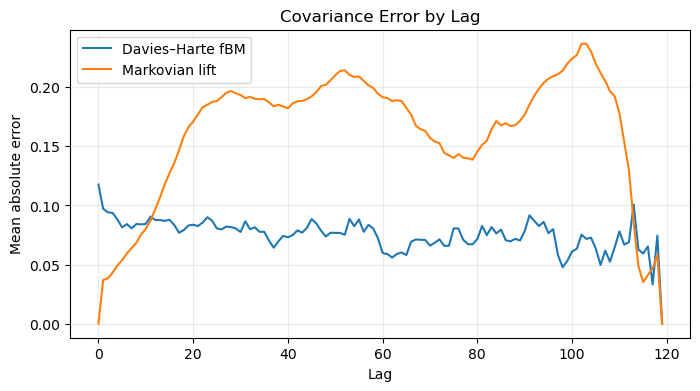

In [9]:
grid = SimulationGrid(120)
hurst = 0.2
fbm = DaviesHarteFractionalBrownianMotion(grid, hurst)
fbm_paths = fbm.simulate(20, seed=120)
fbm_difference, fbm_rmse = covariance_error(fbm_paths, fbm.covariance)
fbm_profile = lagwise_covariance_error(fbm_difference)

lift = MarkovianLift(grid, hurst, factors=10)
lift_paths = lift.simulate(20, seed=320)
lift_difference, lift_rmse = covariance_error(
    lift_paths, fbm_covariance(grid.time, hurst)
)
lift_profile = lagwise_covariance_error(lift_difference)

assert np.all(fbm_paths[:, 0] == 0.0)
assert fbm_profile[-1] == 0.0
assert lift_profile[-1] == 0.0
print(f'fBM covariance RMSE: {fbm_rmse:.4f}')
print(f'Lift covariance RMSE: {lift_rmse:.4f}')
print('Final lag errors:', fbm_profile[-1], lift_profile[-1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fbm_profile, label='Davies–Harte fBM')
ax.plot(lift_profile, label='Markovian lift')
ax.set(title='Covariance Error by Lag', xlabel='Lag', ylabel='Mean absolute error')
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Small HJB smoke test

The reduced grid keeps this notebook check fast while exercising the same classes used by the full experiment.

In [10]:
smoke_params = ModelParams(
    n_steps=24, trading_minutes=24, q_max=2, lift_dim=3,
    y_points=31, mc_paths=12, hurst=0.2, hurst_values=(0.2,),
    representative_seed=17, mc_seed=19,
)
smoke_result = RoughHJBExperiment(smoke_params).run()
print('HJB regimes completed:', sorted(smoke_result))


HJB regimes completed: ['chosen_seed', 'lift', 'mc', 'params', 'regime_label', 'single_hjb', 'single_naive', 'solution']


## Optional use

You can now instantiate any model, dashboard, figure generator, policy simulator, or experiment class directly in new cells. Full article figures can be generated with `ArticleFigureGenerator(Path('generated_figures')).generate()`.